In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.cross_decomposition import CCA

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

In [2]:
# Load and clean data
df = pd.read_csv('HR_data_2.csv')
df_clean = df.dropna().reset_index(drop=True)

print(f"Raw shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")

Raw shape: (312, 71)
Clean shape: (307, 71)


In [3]:
# Features
biosignal_cols = [c for c in df_clean.columns if c.startswith(('HR_TD_', 'TEMP_TD_', 'EDA_TD_'))]
meta_cols = ['Phase', 'Individual', 'Cohort', 'Round', 'Puzzler', 'Team_ID']

X_raw = df_clean[biosignal_cols].astype(float).copy()
meta = df_clean[meta_cols].copy()

In [4]:
# Handle skewness 
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = X_raw.copy()

for subj in meta['Individual'].unique():
    idx = meta['Individual'] == subj
    X_scaled.loc[idx, biosignal_cols] = pt.fit_transform(X_raw.loc[idx])

In [5]:
# Split for CCA 
hr_cols = [c for c in biosignal_cols if c.startswith('HR_TD_')]
eda_temp_cols = [c for c in biosignal_cols if c.startswith(('EDA_TD_', 'TEMP_TD_'))]

X_hr = X_scaled[hr_cols].values
X_eda_temp = X_scaled[eda_temp_cols].values
phase_labels = meta['Phase'].values
individual_ids = meta['Individual'].values

In [6]:
# Run CCA 
n_components = min(X_hr.shape[1], X_eda_temp.shape[1])
cca = CCA(n_components=n_components)
cca.fit(X_hr, X_eda_temp)
X_hr_c, X_eda_temp_c = cca.transform(X_hr, X_eda_temp)

In [7]:
# Canonical correlations
def get_canonical_correlations(cca_model, X, Y):
    X_c, Y_c = cca_model.transform(X, Y)
    return [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(X_c.shape[1])]

canonical_corrs = get_canonical_correlations(cca, X_hr, X_eda_temp)

for i, corr in enumerate(canonical_corrs[:5]):
    print(f"Component {i+1}: {corr:.4f}")

Component 1: 0.7118
Component 2: 0.5219
Component 3: 0.4901
Component 4: 0.4285
Component 5: 0.3901


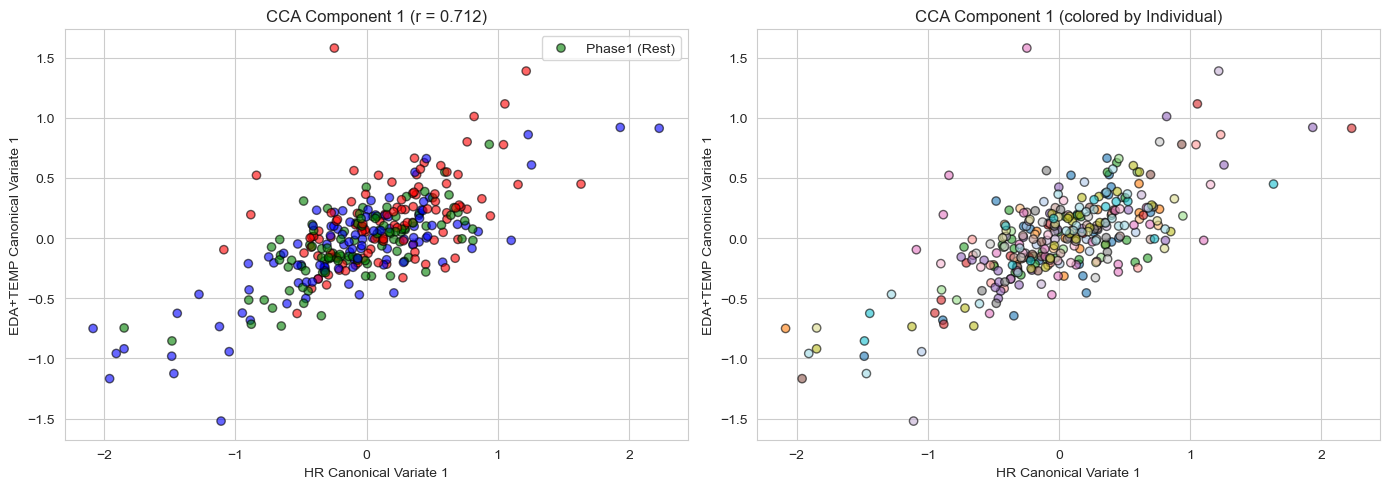

In [11]:
# Visualise canonical variates 
phase_colors = {'phase1': 'blue', 'phase2': 'red', 'phase3': 'green'}
colors = [phase_colors[p] for p in phase_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_hr_c[:, 0], X_eda_temp_c[:, 0], c=colors, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('HR Canonical Variate 1')
axes[0].set_ylabel('EDA+TEMP Canonical Variate 1')
axes[0].set_title(f'CCA Component 1 (r = {canonical_corrs[0]:.3f})')
axes[0].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])

unique_indiv = np.unique(individual_ids)
indiv_colors = {ind: i for i, ind in enumerate(unique_indiv)}
indiv_color_nums = [indiv_colors[ind] for ind in individual_ids]

scatter = axes[1].scatter(X_hr_c[:, 0], X_eda_temp_c[:, 0], c=indiv_color_nums, cmap='tab20', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('HR Canonical Variate 1')
axes[1].set_ylabel('EDA+TEMP Canonical Variate 1')
axes[1].set_title('CCA Component 1 (colored by Individual)')

plt.tight_layout()
plt.show()

In [10]:
print(meta['Phase'].unique())

['phase3' 'phase2' 'phase1']


In [12]:
# Resting vs Puzzle 
resting_mask = meta['Phase'] == 'phase1'
puzzle_mask = meta['Phase'] == 'phase2'

print(f"Phase1 (Resting): {resting_mask.sum()} samples")
print(f"Phase2 (Puzzle): {puzzle_mask.sum()} samples")

cca_resting = CCA(n_components=n_components)
cca_resting.fit(X_hr[resting_mask], X_eda_temp[resting_mask])
X_hr_c_r, X_et_c_r = cca_resting.transform(X_hr[resting_mask], X_eda_temp[resting_mask])
corr_r = np.corrcoef(X_hr_c_r[:, 0], X_et_c_r[:, 0])[0, 1]

cca_puzzle = CCA(n_components=n_components)
cca_puzzle.fit(X_hr[puzzle_mask], X_eda_temp[puzzle_mask])
X_hr_c_p, X_et_c_p = cca_puzzle.transform(X_hr[puzzle_mask], X_eda_temp[puzzle_mask])
corr_p = np.corrcoef(X_hr_c_p[:, 0], X_et_c_p[:, 0])[0, 1]

print(f"Resting (phase1): r = {corr_r:.4f}")
print(f"Puzzle (phase2): r = {corr_p:.4f}")
print(f"Difference (Puzzle - Resting): {corr_p - corr_r:.4f}")

Phase1 (Resting): 100 samples
Phase2 (Puzzle): 104 samples
Resting (phase1): r = 0.9314
Puzzle (phase2): r = 0.8264
Difference (Puzzle - Resting): -0.1050


In [13]:
# Feature loading 
hr_loadings = pd.DataFrame(
    cca.x_rotations_,
    index=hr_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.x_rotations_.shape[1])]
)

print("\nHR Features (top 5 on Component 1):")
hr_sorted = hr_loadings['Comp_1'].abs().sort_values(ascending=False)
for i, (feature, loading) in enumerate(hr_sorted.head(5).items()):
    sign = '+' if hr_loadings.loc[feature, 'Comp_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")

et_loadings = pd.DataFrame(
    cca.y_rotations_,
    index=eda_temp_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.y_rotations_.shape[1])]
)

print("\nEDA+TEMP Features (top 5 on Component 1):")
et_sorted = et_loadings['Comp_1'].abs().sort_values(ascending=False)
for i, (feature, loading) in enumerate(et_sorted.head(5).items()):
    sign = '+' if et_loadings.loc[feature, 'Comp_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")


HR Features (top 5 on Component 1):
  1. HR_TD_AUC: +0.780
  2. HR_TD_Mean: -0.425
  3. HR_TD_Slope: +0.292
  4. HR_TD_Slope_mean: -0.273
  5. HR_TD_Max: +0.145

EDA+TEMP Features (top 5 on Component 1):
  1. EDA_TD_T_AUC: +0.548
  2. EDA_TD_T_Mean: -0.488
  3. TEMP_TD_Mean: -0.360
  4. TEMP_TD_Min: +0.352
  5. EDA_TD_P_std: -0.182


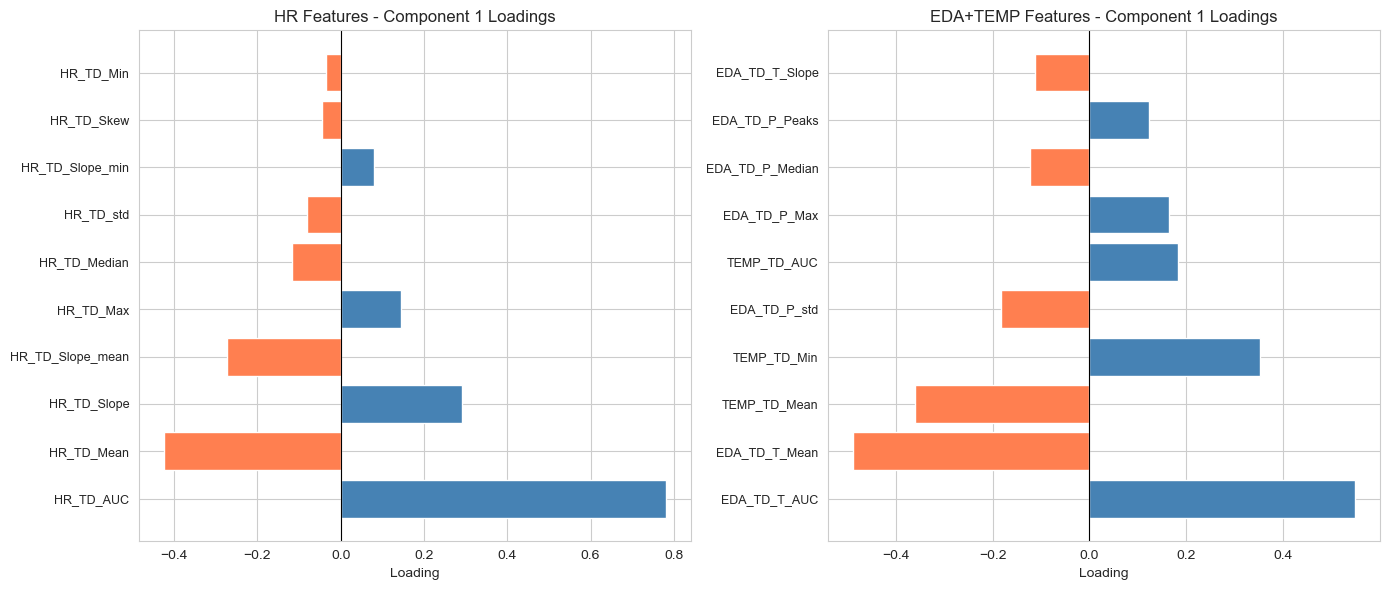

In [16]:
# Visualise top feature loadings 
hr_loadings = pd.DataFrame(
    cca.x_rotations_,
    index=hr_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.x_rotations_.shape[1])]
)

hr_top10 = hr_loadings['Comp_1'].abs().sort_values(ascending=False).head(10)
hr_top10_signed = hr_loadings.loc[hr_top10.index, 'Comp_1']

# Get top 10 EDA+TEMP loadings for Component 1
et_loadings = pd.DataFrame(
    cca.y_rotations_,
    index=eda_temp_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.y_rotations_.shape[1])]
)

et_top10 = et_loadings['Comp_1'].abs().sort_values(ascending=False).head(10)
et_top10_signed = et_loadings.loc[et_top10.index, 'Comp_1']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HR loadings
colors_hr = ['steelblue' if x > 0 else 'coral' for x in hr_top10_signed.values]
axes[0].barh(range(len(hr_top10_signed)), hr_top10_signed.values, color=colors_hr)
axes[0].set_yticks(range(len(hr_top10_signed)))
axes[0].set_yticklabels(hr_top10_signed.index, fontsize=9)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Loading')
axes[0].set_title('HR Features - Component 1 Loadings')

# EDA+TEMP loadings
colors_et = ['steelblue' if x > 0 else 'coral' for x in et_top10_signed.values]
axes[1].barh(range(len(et_top10_signed)), et_top10_signed.values, color=colors_et)
axes[1].set_yticks(range(len(et_top10_signed)))
axes[1].set_yticklabels(et_top10_signed.index, fontsize=9)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Loading')
axes[1].set_title('EDA+TEMP Features - Component 1 Loadings')

plt.tight_layout()
plt.show()

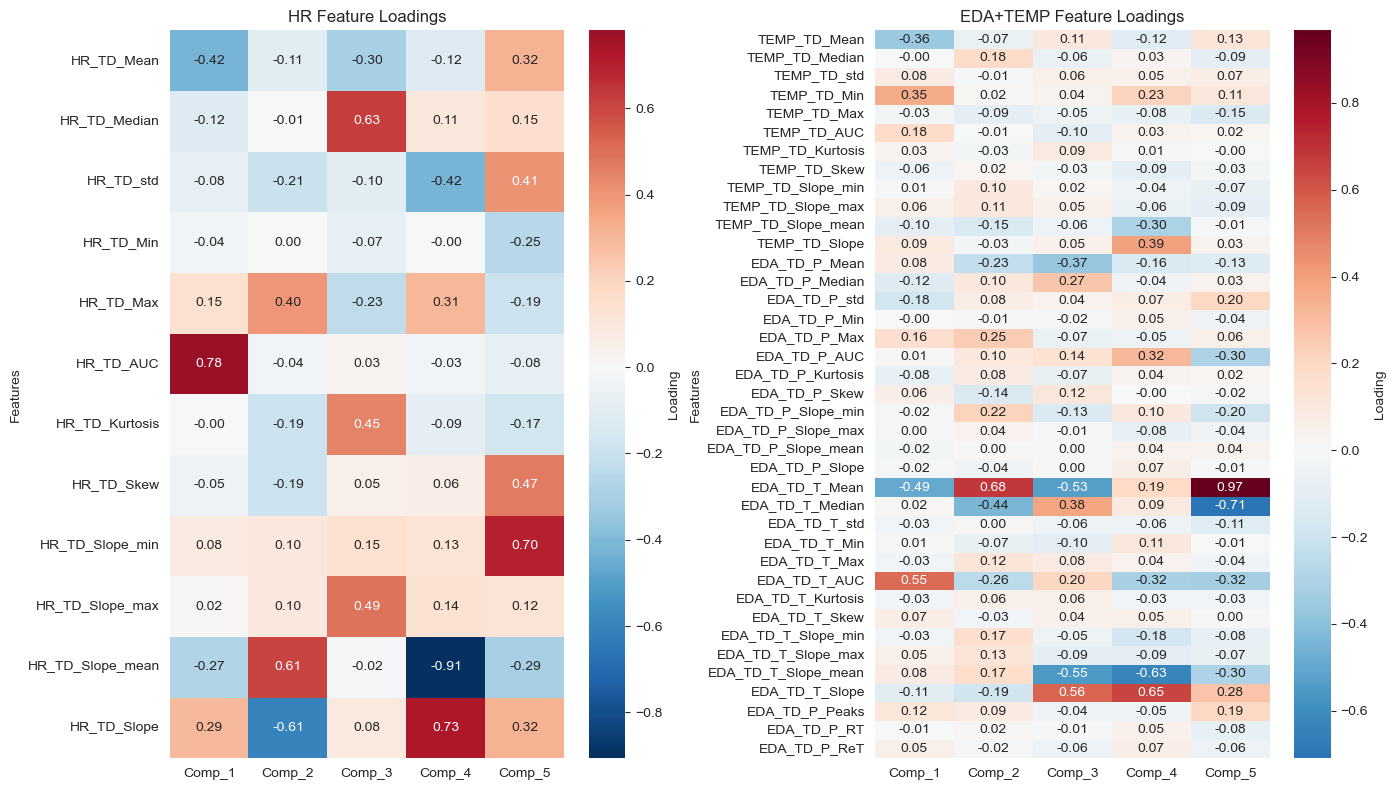

In [17]:
# Heatmap of loadings
hr_loadings_small = hr_loadings.iloc[:, :min(5, hr_loadings.shape[1])]
et_loadings_small = et_loadings.iloc[:, :min(5, et_loadings.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# HR heatmap
sns.heatmap(hr_loadings_small, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[0], cbar_kws={'label': 'Loading'})
axes[0].set_title('HR Feature Loadings')
axes[0].set_ylabel('Features')

# EDA+TEMP heatmap
sns.heatmap(et_loadings_small, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[1], cbar_kws={'label': 'Loading'})
axes[1].set_title('EDA+TEMP Feature Loadings')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()